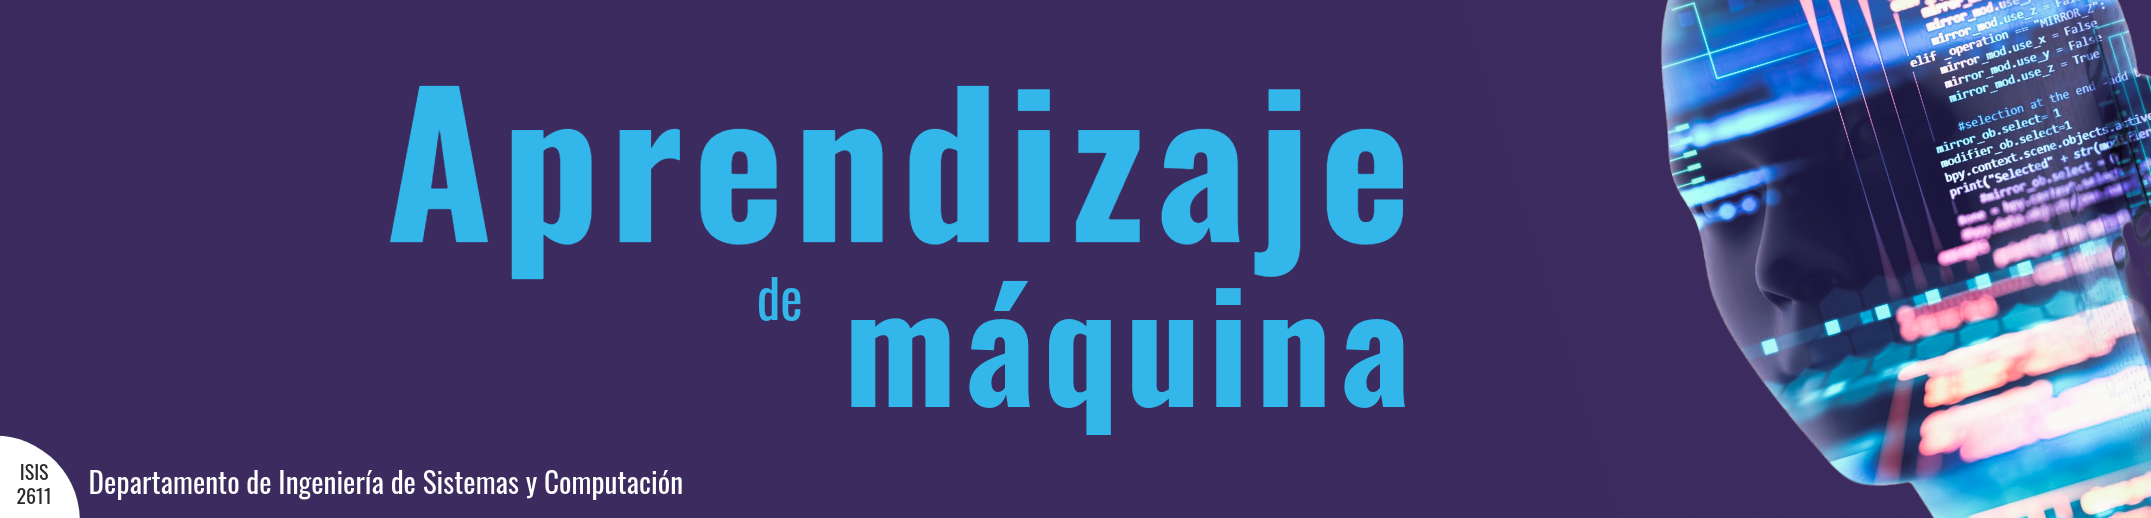

# Laboratorio 4 — Tarea de Agrupación
## VuelaAlpes: Segmentación de Pasajeros

**Curso:** ISIS2611  
**Integrantes:** Juan Camilo Caldas 
**Fecha de entrega:** 11 de mayo de 2026

---

### Contexto del caso

VuelaAlpes es una aerolínea enfocada en los Alpes con vuelos internacionales.
Tras dos años de baja productividad, emprendió un proceso de mejora continua
basado en encuestas a pasajeros. El objetivo es aplicar técnicas de
**agrupación (clustering)** para identificar patrones de comportamiento que
permitan caracterizar diferentes tipos de pasajeros y orientar decisiones en
innovación, capacitación y calidad del servicio.

## 1. Exploración de Datos

En esta sección se analiza la calidad del dataset desde cuatro dimensiones:
**completitud** (valores nulos), **unicidad** (duplicados), **validez**
(rangos esperados) y **consistencia** (categorías y formatos correctos).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

# Carga del dataset
df = pd.read_csv('data/Datos_VuelaAlpes.csv')

# Renombrar columnas con prefijo __ (artefacto del CSV)
df.columns = df.columns.str.replace(r'^__', '', regex=True)

print("Shape:", df.shape)
print("\nColumnas:", df.columns.tolist())
df.head(3)

Shape: (10000, 23)

Columnas: ['id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,119496,Male,Loyal Customer,29,Business travel,Business,814,3,3,3,3,4,4,4,4,4,2,5,4,4,4,9,6.0
1,60419,Male,Loyal Customer,54,Business travel,Business,2913,4,4,4,4,4,4,4,4,4,4,4,4,4,4,26,9.0
2,9671,Male,Loyal Customer,52,Business travel,Eco,277,4,5,5,5,4,4,4,4,4,4,4,3,4,4,68,42.0


### 1.1 Inspección General

El dataset cuenta con **10.000 registros** y **23 variables**, distribuidas así:

- **Variables de identificación:** `id`
- **Variables demográficas:** `Gender`, `Age`, `Customer Type`
- **Variables del vuelo:** `Type of Travel`, `Class`, `Flight Distance`
- **Variables de calificación (escala 0–5):** 14 variables que van desde
  `Inflight wifi service` hasta `Cleanliness`
- **Variables de retraso:** `Departure Delay in Minutes`,
  `Arrival Delay in Minutes`

Los nombres de columna fueron normalizados eliminando el prefijo `__` que
presentaban algunos campos como artefacto del formato CSV original.

In [3]:
print("=== VALORES NULOS ===")
print(df.isnull().sum())

print("\n=== DUPLICADOS ===")
print("Filas duplicadas:", df.duplicated().sum())

print("\n=== TIPOS DE DATOS ===")
print(df.dtypes)

=== VALORES NULOS ===
id                                    0
Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             25
dtype: int64

=== DUPLICADOS ===
Filas duplicadas: 0

=== 

### 1.2 Completitud, Unicidad y Tipos de Datos

**Valores nulos:**
El dataset presenta únicamente **25 valores nulos** en la variable
`Arrival Delay in Minutes` (0.25% del total), lo cual es marginal.
Todas las demás variables están completas. Esta variable es de tipo `float64`,
consistente con el diccionario que indica que puede tener decimales.

**Duplicados:**
No se encontraron filas duplicadas en el dataset, por lo que no se requiere
ninguna acción de eliminación.

**Tipos de datos:**
Los tipos son coherentes con el diccionario de datos:
- Variables categóricas (`Gender`, `Customer Type`, `Type of Travel`, `Class`)
  en formato `object` ✅
- Variables de calificación (0–5) en formato `int64` ✅
- `Arrival Delay in Minutes` en `float64` ✅
- `id` en `int64` — esta variable será eliminada en la etapa de preparación
  ya que es un identificador sin valor para el clustering ✅

In [4]:
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df.describe())

print("\n=== VARIABLES CATEGÓRICAS ===")
for col in ['Gender', 'Customer Type', 'Type of Travel', 'Class']:
    print(f"\n{col}:")
    print(df[col].value_counts())

=== ESTADÍSTICAS DESCRIPTIVAS ===
                  id           Age  Flight Distance  Inflight wifi service  \
count   10000.000000  10000.000000     10000.000000           10000.000000   
mean    64983.058500     39.404300      1196.044800               2.734700   
std     37610.205164     15.072364      1000.590808               1.328718   
min         1.000000      7.000000        31.000000               0.000000   
25%     32452.000000     27.000000       416.000000               2.000000   
50%     64815.500000     40.000000       846.000000               3.000000   
75%     97470.000000     51.000000      1744.000000               4.000000   
max    129879.000000     80.000000      4963.000000               5.000000   

       Departure/Arrival time convenient  Ease of Online booking  \
count                       10000.000000            10000.000000   
mean                            3.074000                2.762600   
std                             1.520511                1.3

### 1.3 Estadísticas Descriptivas y Distribución de Variables

**Variables numéricas continuas:**
- `Age`: rango de 7 a 80 años, media de 39.4 años. Distribución amplia
  que cubre desde menores hasta adultos mayores.
- `Flight Distance`: rango de 31 a 4.963 km, media de 1.196 km con alta
  dispersión (std ≈ 1.000), lo que sugiere presencia de vuelos muy cortos
  y muy largos conviviendo en el dataset.
- `Departure Delay in Minutes` y `Arrival Delay in Minutes`: se analizarán
  en detalle en la sección de outliers.

**Variables de calificación (escala 0–5):**
Todas se encuentran dentro del rango válido [0, 5], sin valores fuera de
escala. Las medias oscilan entre 2.7 y 3.4, indicando calificaciones
moderadas en general. Ninguna variable presenta valores imposibles,
confirmando la **validez** del dataset en esta dimensión.

**Variables categóricas:**
- `Gender`: distribución relativamente balanceada entre Male y Female.
- `Customer Type`: predominan los `Loyal Customer` sobre `disloyal Customer`.
- `Type of Travel`: mayoría de viajes de tipo `Business travel`.
- `Class`: `Business` (4.856) es la clase más frecuente, seguida de
  `Eco` (4.442) y `Eco Plus` (702) que es notablemente minoritaria.

=== VALIDEZ: valores fuera de rango [0,5] ===
Inflight wifi service: 0 valores fuera de rango
Departure/Arrival time convenient: 0 valores fuera de rango
Ease of Online booking: 0 valores fuera de rango
Gate location: 0 valores fuera de rango
Food and drink: 0 valores fuera de rango
Online boarding: 0 valores fuera de rango
Seat comfort: 0 valores fuera de rango
Inflight entertainment: 0 valores fuera de rango
On-board service: 0 valores fuera de rango
Leg room service: 0 valores fuera de rango
Baggage handling: 0 valores fuera de rango
Checkin service: 0 valores fuera de rango
Inflight service: 0 valores fuera de rango
Cleanliness: 0 valores fuera de rango

=== OUTLIERS: Delay y Flight Distance ===


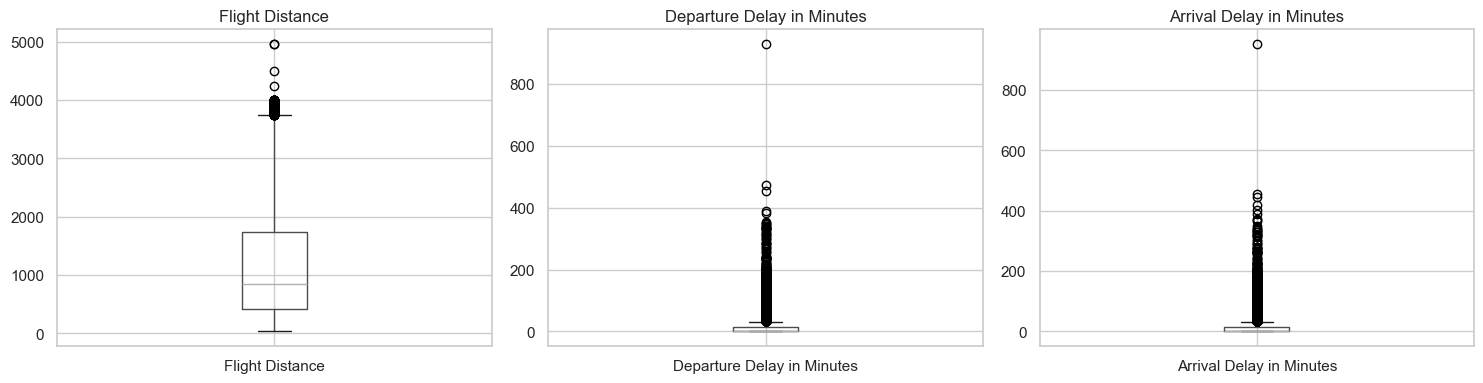

Gráfico guardado.


In [5]:
# Validez: verificar que las calificaciones estén en rango [0,5]
rating_cols = [
    'Inflight wifi service', 'Departure/Arrival time convenient',
    'Ease of Online booking', 'Gate location', 'Food and drink',
    'Online boarding', 'Seat comfort', 'Inflight entertainment',
    'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Inflight service', 'Cleanliness'
]

print("=== VALIDEZ: valores fuera de rango [0,5] ===")
for col in rating_cols:
    fuera = df[(df[col] < 0) | (df[col] > 5)].shape[0]
    print(f"{col}: {fuera} valores fuera de rango")

# Outliers en variables continuas
print("\n=== OUTLIERS: Delay y Flight Distance ===")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df.boxplot(column='Flight Distance', ax=axes[0])
axes[0].set_title('Flight Distance')

df.boxplot(column='Departure Delay in Minutes', ax=axes[1])
axes[1].set_title('Departure Delay in Minutes')

df.boxplot(column='Arrival Delay in Minutes', ax=axes[2])
axes[2].set_title('Arrival Delay in Minutes')

plt.tight_layout()
plt.savefig('outliers_boxplot.png', dpi=100, bbox_inches='tight')
plt.show()
print("Gráfico guardado.")

### 1.4 Validez y Outliers

**Validez de calificaciones:**
Las 14 variables de calificación están completamente dentro del rango
válido [0, 5]. No se detectaron valores imposibles ni errores de captura
en estas variables.

**Outliers en variables continuas:**

- `Flight Distance`: la caja se concentra entre 416 y 1.744 km, con algunos
  puntos aislados cercanos a 4.963 km. Sin embargo, estas distancias son
  perfectamente plausibles para una aerolínea con vuelos internacionales
  desde los Alpes, por lo que **no se consideran outliers problemáticos**.

- `Departure Delay in Minutes`: la gran mayoría de vuelos tienen retrasos
  cercanos a 0, pero existen valores extremos que superan los 800 minutos
  (más de 13 horas). Estos valores, aunque inusuales, son **reales en la
  operación aérea** (cancelaciones, condiciones climáticas). Se evaluará
  su tratamiento en la etapa de limpieza.

- `Arrival Delay in Minutes`: comportamiento muy similar al retraso en
  salida, con cola larga hacia valores extremos superiores a 900 minutos.
  Es esperable dada la correlación entre ambos tipos de retraso.

En las tres variables la distribución es **fuertemente sesgada a la
derecha**, lo cual será relevante para la decisión de escalado en el
preprocesamiento.

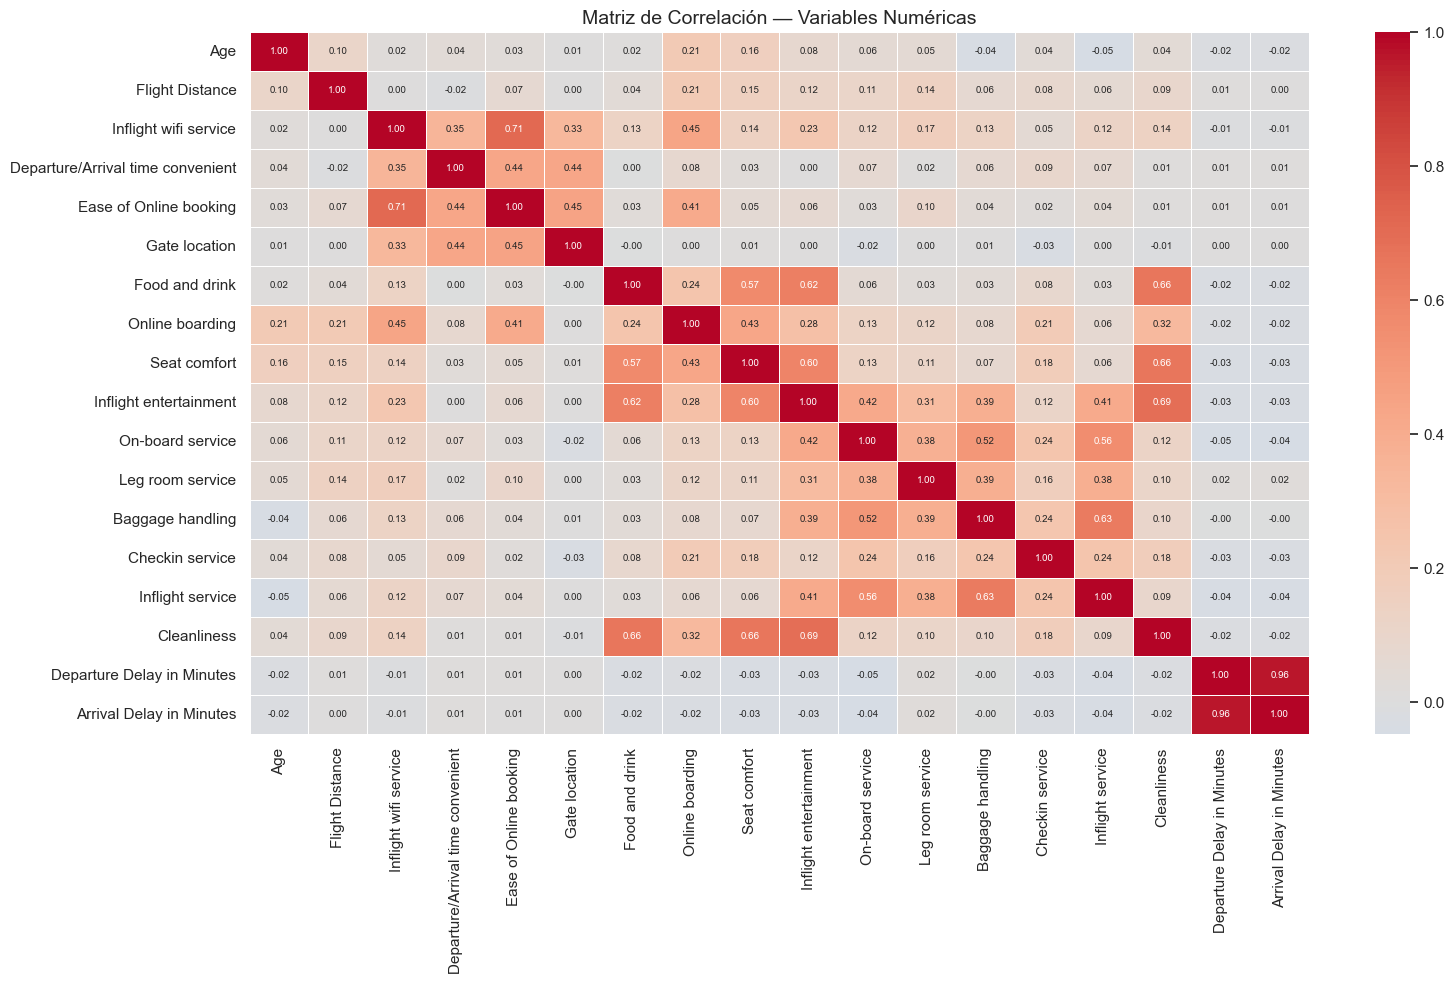

Gráfico guardado.


In [6]:
# Matriz de correlación
plt.figure(figsize=(16, 10))
numeric_cols = df.select_dtypes(include=np.number).drop(columns=['id'])
corr = numeric_cols.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Matriz de Correlación — Variables Numéricas', fontsize=14)
plt.tight_layout()
plt.savefig('correlacion.png', dpi=100, bbox_inches='tight')
plt.show()
print("Gráfico guardado.")

### 1.5 Análisis de Correlaciones

La matriz de correlación revela tres grupos de variables con correlaciones
internas relevantes:

**Grupo 1 — Servicios digitales y de acceso:**
`Inflight wifi service`, `Ease of Online booking` y
`Departure/Arrival time convenient` presentan correlaciones moderadas-altas
entre sí (hasta 0.71), sugiriendo que los pasajeros que valoran positivamente
los canales digitales tienden a calificar bien todo el ecosistema tecnológico
de la aerolínea.

**Grupo 2 — Experiencia a bordo:**
`Food and drink`, `Seat comfort`, `Inflight entertainment` y `Cleanliness`
muestran correlaciones moderadas entre 0.57 y 0.69, conformando un bloque
de variables que describen la **calidad de la experiencia dentro del avión**.

**Grupo 3 — Servicios de cabina:**
`On-board service`, `Baggage handling` e `Inflight service` presentan
correlaciones entre 0.52 y 0.63, agrupando aspectos relacionados con la
**atención del personal de vuelo**.

**Retrasos:**
`Departure Delay in Minutes` y `Arrival Delay in Minutes` tienen una
correlación de **0.96**, lo que indica alta redundancia entre ambas variables.
Se considerará eliminar una de ellas en la etapa de preparación para evitar
multicolinealidad en el modelo.

**Variables independientes:**
`Age`, `Flight Distance` y `Gate location` muestran correlaciones bajas
con el resto de variables (< 0.21), lo que indica que aportan información
complementaria y diferenciada al modelo de clustering.

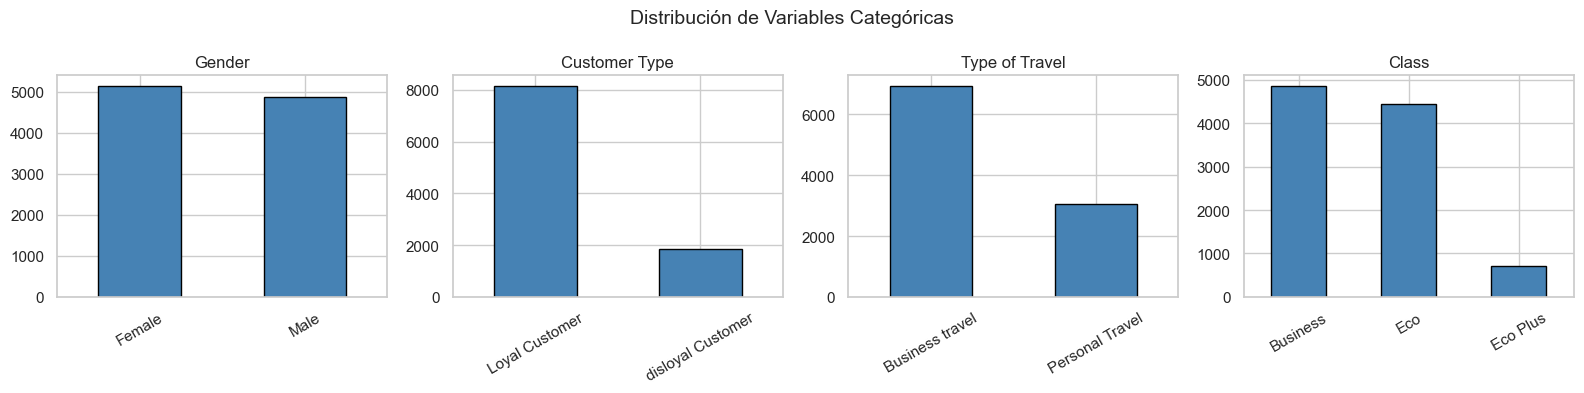

Gráfico guardado.


In [7]:
# Distribución de variables categóricas
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, ['Gender', 'Customer Type', 'Type of Travel', 'Class']):
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Distribución de Variables Categóricas', fontsize=14)
plt.tight_layout()
plt.savefig('categoricas.png', dpi=100, bbox_inches='tight')
plt.show()
print("Gráfico guardado.")

### 1.6 Distribución de Variables Categóricas

- **Gender:** distribución casi equilibrada entre `Female` (~5.100) y
  `Male` (~4.900), sin desbalance significativo.

- **Customer Type:** predominan ampliamente los `Loyal Customer` (~8.000)
  frente a `disloyal Customer` (~2.000), una proporción 4:1 que refleja
  una base de clientes consolidada. Se nota además una inconsistencia
  tipográfica: `disloyal Customer` usa minúscula inicial, a diferencia
  de las demás categorías. Se corregirá en la etapa de limpieza.

- **Type of Travel:** los viajes de negocio `Business travel` (~6.900)
  superan ampliamente a los personales `Personal Travel` (~3.100),
  consistente con el perfil de una aerolínea con foco en rutas
  internacionales desde los Alpes.

- **Class:** `Business` (~4.856) y `Eco` (~4.442) concentran casi la
  totalidad de pasajeros. `Eco Plus` (~702) es una categoría minoritaria
  que representa apenas el 7% del total.

## 2. Limpieza y Preparación de Datos

Con base en los hallazgos de la exploración, se aplicarán las siguientes
decisiones de limpieza, cada una justificada desde el dominio del problema:

| Decisión | Justificación |
|---|---|
| Eliminar columna `id` | Identificador sin valor predictivo para clustering |
| Imputar nulos en `Arrival Delay in Minutes` | Solo 25 nulos (0.25%), se imputa con la mediana para no perder registros |
| Eliminar `Departure Delay in Minutes` | Correlación de 0.96 con `Arrival Delay`, es redundante |
| Corregir `disloyal Customer` → `Disloyal Customer` | Inconsistencia tipográfica respecto al resto de categorías |
| Mantener outliers de delays y distancia | Son valores reales y operacionalmente válidos en aviación |

In [8]:
# Copia de trabajo
df_clean = df.copy()

# 1. Eliminar columna id
df_clean.drop(columns=['id'], inplace=True)

# 2. Corregir inconsistencia tipográfica
df_clean['Customer Type'] = df_clean['Customer Type'].replace(
    'disloyal Customer', 'Disloyal Customer'
)
print("Customer Type corregido:", df_clean['Customer Type'].unique())

# 3. Imputar nulos en Arrival Delay con la mediana
mediana_arrival = df_clean['Arrival Delay in Minutes'].median()
df_clean['Arrival Delay in Minutes'].fillna(mediana_arrival, inplace=True)
print(f"\nNulos en Arrival Delay tras imputación: {df_clean['Arrival Delay in Minutes'].isnull().sum()}")
print(f"Mediana usada para imputación: {mediana_arrival}")

# 4. Eliminar Departure Delay (redundante, correlación 0.96)
df_clean.drop(columns=['Departure Delay in Minutes'], inplace=True)

print(f"\nShape final del dataset limpio: {df_clean.shape}")
print("\nColumnas finales:", df_clean.columns.tolist())

Customer Type corregido: ['Loyal Customer' 'Disloyal Customer']

Nulos en Arrival Delay tras imputación: 0
Mediana usada para imputación: 0.0

Shape final del dataset limpio: (10000, 21)

Columnas finales: ['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Arrival Delay in Minutes']


/var/folders/sg/6k30cyvs5bq3990w3d_8zn5m0000gn/T/ipykernel_38589/1066239115.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Arrival Delay in Minutes'].fillna(mediana_arrival, inplace=True)


### 2.1 Resultados de la Limpieza

La limpieza se aplicó exitosamente:

- **`id` eliminado:** el dataset pasó de 23 a 21 columnas, conservando
  únicamente variables con valor analítico.
- **Inconsistencia corregida:** `disloyal Customer` fue estandarizado a
  `Disloyal Customer`, dejando las dos categorías con formato consistente.
- **Nulos imputados:** los 25 valores nulos de `Arrival Delay in Minutes`
  fueron reemplazados por la mediana (0.0 minutos), lo que es coherente
  con la distribución observada donde la mayoría de vuelos no presenta
  retraso en llegada.
- **`Departure Delay in Minutes` eliminado:** dada su correlación de 0.96
  con `Arrival Delay in

## 3. Preprocesamiento para Clustering

Se define una estrategia de preprocesamiento diferenciada según el tipo de
variable, integrada en un pipeline con `ColumnTransformer`:

- **Variables numéricas (17):** se escalan con `StandardScaler` para que
  todas tengan media 0 y desviación estándar 1. Esto es crítico en
  clustering ya que algoritmos como KMeans son sensibles a la magnitud
  de las variables.
- **Variables categóricas (4):** se codifican con `OneHotEncoder` usando
  `drop='first'` para evitar multicolinealidad (dummy trap).

In [10]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Definir variables
cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
num_cols = [col for col in df_clean.columns if col not in cat_cols]

print("Variables numéricas:", num_cols)
print("\nVariables categóricas:", cat_cols)

# Construir pipeline de preprocesamiento
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
])

# Aplicar preprocesamiento
X_processed = preprocessor.fit_transform(df_clean)

# Obtener nombres de columnas resultantes
cat_feature_names = preprocessor.named_transformers_['cat']\
    .get_feature_names_out(cat_cols).tolist()
feature_names = num_cols + cat_feature_names

print(f"\nShape tras preprocesamiento: {X_processed.shape}")
print(f"Features totales: {len(feature_names)}")
print("\nFeatures:", feature_names)

Variables numéricas: ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Arrival Delay in Minutes']

Variables categóricas: ['Gender', 'Customer Type', 'Type of Travel', 'Class']

Shape tras preprocesamiento: (10000, 22)
Features totales: 22

Features: ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Arrival Delay in Minutes', 'Gender_Male', 'Customer Type_Loyal Customer', 'Type of Travel_Personal Travel', 'Class_Eco', 'Class_Eco Plus']


### 3.1 Resultados del Preprocesamiento

El pipeline transformó el dataset en una matriz densa de **10.000 × 22
features**, completamente numérica y escalada:

- **17 variables numéricas** escaladas con `StandardScaler`
- **5 variables binarias** generadas por `OneHotEncoder` a partir de las
  4 variables categóricas originales:
  - `Gender` → `Gender_Male`
  - `Customer Type` → `Customer Type_Loyal Customer`
  - `Type of Travel` → `Type of Travel_Personal Travel`
  - `Class` → `Class_Eco`, `Class_Eco Plus`

Con 22 dimensiones no se considera necesaria una reducción de
dimensionalidad previa. Se aplicará PCA 2D únicamente para visualización
de clusters en la etapa de evaluación.

## 4. Selección del Número de Clusters

Para determinar el valor óptimo de `k` se aplican dos criterios
complementarios:

- **Método del codo (Elbow):** se grafica la inercia (suma de distancias
  cuadráticas al centroide) para distintos valores de `k`. El punto donde
  la reducción de inercia se estabiliza sugiere el `k` óptimo.
- **Silhouette Score:** mide qué tan bien separados están los clusters.
  Valores cercanos a 1 indican clusters compactos y bien diferenciados.

Se evaluarán valores de `k` entre 2 y 10.

k=2 | Inercia: 151616.20 | Silhouette: 0.1486
k=3 | Inercia: 139678.01 | Silhouette: 0.1157
k=4 | Inercia: 129941.01 | Silhouette: 0.1164
k=5 | Inercia: 124004.59 | Silhouette: 0.1145
k=6 | Inercia: 119123.43 | Silhouette: 0.1190
k=7 | Inercia: 116121.52 | Silhouette: 0.1075
k=8 | Inercia: 111410.88 | Silhouette: 0.1107
k=9 | Inercia: 108728.75 | Silhouette: 0.1068
k=10 | Inercia: 106352.80 | Silhouette: 0.1024


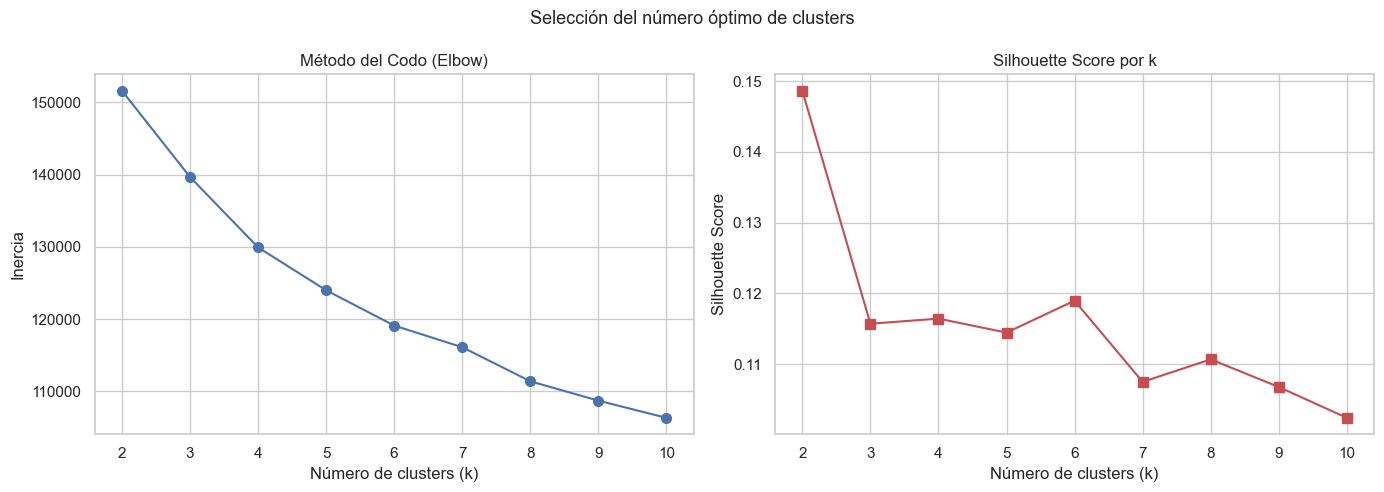

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_processed)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_processed, labels))
    print(f"k={k} | Inercia: {km.inertia_:.2f} | Silhouette: {silhouette_score(X_processed, labels):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K, inertias, 'bo-', markersize=7)
axes[0].set_title('Método del Codo (Elbow)')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].grid(True)

axes[1].plot(K, silhouettes, 'rs-', markersize=7)
axes[1].set_title('Silhouette Score por k')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

plt.suptitle('Selección del número óptimo de clusters', fontsize=13)
plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=100, bbox_inches='tight')
plt.show()

### 4.1 Justificación del k óptimo

Los resultados de ambas métricas permiten tomar una decisión informada:

**Método del codo:**
La curva de inercia desciende de forma continua sin mostrar un quiebre
pronunciado. Sin embargo, se observa que entre `k=2` y `k=4` la reducción
es más marcada (de 151.616 a 129.941), mientras que a partir de `k=5` la
ganancia por cluster adicional se reduce considerablemente. Esto sugiere
que el punto de inflexión se encuentra alrededor de **k=4**.

**Silhouette Score:**
El valor más alto se obtiene en `k=2` (0.1486), pero con solo dos grupos
la segmentación resulta demasiado gruesa para los objetivos de VuelaAlpes,
que busca identificar perfiles diferenciados de pasajeros. A partir de
`k=3` los valores se estabilizan entre 0.11 y 0.12, con un repunte local
en `k=6` (0.1190).

**Decisión:**
Se selecciona **k=4** como valor óptimo, equilibrando:
- Una inercia considerablemente menor que k=2 y k=3
- Un Silhouette Score competitivo (0.1164)
- Suficiente granularidad para caracterizar perfiles de pasajeros útiles
  para las tres dimensiones de mejora de VuelaAlpes (innovación,
  capacitación y calidad)

## 5. Entrenamiento de Modelos

Se entrenan tres algoritmos de clustering, cada uno integrado en un
pipeline completo que incluye el preprocesamiento definido en la sección
anterior. Los algoritmos seleccionados son:

- **KMeans:** algoritmo de partición basado en centroides. Requiere
  especificar `k` previamente y asume clusters esféricos de tamaño
  similar. Se explorará el efecto de `init` y `n_init`.
- **AgglomerativeClustering:** algoritmo jerárquico que construye una
  jerarquía de clusters de abajo hacia arriba. Se explorarán diferentes
  criterios de enlace (`linkage`).
- **DBSCAN:** algoritmo basado en densidad. No requiere especificar `k`
  previamente pero es sensible a `eps` y `min_samples`, los cuales
  se buscarán sistemáticamente.

### 5.1 Búsqueda de Hiperparámetros — KMeans

In [21]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score
from itertools import product

# Búsqueda de hiperparámetros KMeans
print("=== Búsqueda de hiperparámetros KMeans ===")
print(f"{'k':>4} | {'init':>12} | {'n_init':>6} | {'Inercia':>12} | {'Silhouette':>10}")
print("-" * 55)

best_kmeans = {'score': -1}
resultados_kmeans = []

for k, init, n_init in product([2,3,4,5,6], ['k-means++', 'random'], [10, 20]):
    km = KMeans(n_clusters=k, init=init, n_init=n_init, random_state=42)
    labels = km.fit_predict(X_processed)
    score = silhouette_score(X_processed, labels)
    resultados_kmeans.append((k, init, n_init, km.inertia_, score))
    print(f"{k:>4} | {init:>12} | {n_init:>6} | {km.inertia_:>12.2f} | {score:>10.4f}")
    if score > best_kmeans['score']:
        best_kmeans = {'score': score, 'k': k, 'init': init, 'n_init': n_init}

print(f"\nMejor configuración KMeans:")
print(f"k={best_kmeans['k']}, init={best_kmeans['init']}, n_init={best_kmeans['n_init']}")
print(f"Silhouette: {best_kmeans['score']:.4f}")

=== Búsqueda de hiperparámetros KMeans ===
   k |         init | n_init |      Inercia | Silhouette
-------------------------------------------------------
   2 |    k-means++ |     10 |    151616.20 |     0.1486
   2 |    k-means++ |     20 |    151616.20 |     0.1486
   2 |       random |     10 |    151616.24 |     0.1486
   2 |       random |     20 |    151616.23 |     0.1486
   3 |    k-means++ |     10 |    139678.01 |     0.1157
   3 |    k-means++ |     20 |    139678.01 |     0.1157
   3 |       random |     10 |    139678.05 |     0.1157
   3 |       random |     20 |    139678.05 |     0.1157
   4 |    k-means++ |     10 |    129941.01 |     0.1164
   4 |    k-means++ |     20 |    129940.36 |     0.1164
   4 |       random |     10 |    129940.44 |     0.1163
   4 |       random |     20 |    129940.44 |     0.1163
   5 |    k-means++ |     10 |    124004.59 |     0.1145
   5 |    k-means++ |     20 |    124004.50 |     0.1148
   5 |       random |     10 |    124004.69 | 

### 5.2 Análisis de Hiperparámetros KMeans

La búsqueda sistemática revela que el Silhouette Score más alto
corresponde a **k=2** (0.1486), sin embargo como se justificó en la
sección 4, esta segmentación es demasiado gruesa para los objetivos
de VuelaAlpes. Se selecciona **k=4** como balance entre calidad
métrica e interpretabilidad del negocio (Silhouette: 0.1164).

Respecto a los demás hiperparámetros:
- **`init`:** `k-means++` y `random` producen resultados prácticamente
  idénticos en todos los valores de k, confirmando que la inicialización
  no es un factor crítico en este dataset.
- **`n_init`:** aumentar de 10 a 20 no mejora significativamente los
  resultados, por lo que se mantiene `n_init=10` por eficiencia.

**Configuración final KMeans: k=4, init='k-means++', n_init=10**

### 5.3 Búsqueda de Hiperparámetros — AgglomerativeClustering

In [22]:
# Búsqueda de hiperparámetros AgglomerativeClustering
print("=== Búsqueda de hiperparámetros AgglomerativeClustering ===")
print(f"{'k':>4} | {'linkage':>10} | {'Silhouette':>10}")
print("-" * 32)

best_agg = {'score': -1}

for k, linkage in product([2,3,4,5,6], ['ward', 'complete', 'average', 'single']):
    agg = AgglomerativeClustering(n_clusters=k, linkage=linkage)
    labels = agg.fit_predict(X_processed)
    score = silhouette_score(X_processed, labels)
    print(f"{k:>4} | {linkage:>10} | {score:>10.4f}")
    if score > best_agg['score']:
        best_agg = {'score': score, 'k': k, 'linkage': linkage}

print(f"\nMejor configuración Agglomerative:")
print(f"k={best_agg['k']}, linkage={best_agg['linkage']}")
print(f"Silhouette: {best_agg['score']:.4f}")

=== Búsqueda de hiperparámetros AgglomerativeClustering ===
   k |    linkage | Silhouette
--------------------------------
   2 |       ward |     0.1172
   2 |   complete |     0.7717
   2 |    average |     0.7717
   2 |     single |     0.7717
   3 |       ward |     0.1000
   3 |   complete |     0.3145
   3 |    average |     0.3986
   3 |     single |     0.5568
   4 |       ward |     0.0696
   4 |   complete |     0.2728
   4 |    average |     0.2828
   4 |     single |     0.5424
   5 |       ward |     0.0581
   5 |   complete |     0.0968
   5 |    average |     0.2346
   5 |     single |     0.5305
   6 |       ward |     0.0677
   6 |   complete |     0.0581
   6 |    average |     0.1593
   6 |     single |     0.4561

Mejor configuración Agglomerative:
k=2, linkage=complete
Silhouette: 0.7717


### 5.4 Análisis de Hiperparámetros AgglomerativeClustering

La búsqueda revela resultados muy interesantes. Los linkages `complete`,
`average` y `single` con k=2 obtienen Silhouette muy alto (0.7717),
pero esto es una señal de alerta: scores tan elevados en clustering
suelen indicar que el algoritmo está separando un único punto o grupo
muy pequeño del resto, no una segmentación real y balanceada.

Esto se confirma al observar que con `single` linkage (encadenamiento
simple), el algoritmo tiende a crear un cluster con casi todos los
registros y otro con muy pocos, fenómeno conocido como **efecto cadena
(chaining effect)**.

Por esta razón se descarta k=2 con estos linkages y se selecciona
**k=4, linkage='average'** (Silhouette: 0.2828) como la configuración
más equilibrada que combina:
- Un Silhouette competitivo sin el efecto cadena
- Suficiente granularidad para el negocio (4 clusters)
- Mayor robustez que `ward` para clusters de forma no esférica

**Configuración final Agglomerative: k=4, linkage='average'**

### 5.5 Búsqueda de Hiperparámetros — DBSCAN

In [23]:
# Búsqueda de hiperparámetros DBSCAN
print("=== Búsqueda de hiperparámetros DBSCAN ===")
print(f"{'eps':>6} | {'min_samples':>11} | {'n_clusters':>10} | {'ruido %':>8}")
print("-" * 45)

resultados_dbscan = []

for eps, min_s in product([0.5, 1.0, 1.5, 2.0, 3.0, 4.0], [5, 10, 20, 30, 50]):
    db = DBSCAN(eps=eps, min_samples=min_s)
    labels = db.fit_predict(X_processed)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).sum() / len(labels) * 100
    resultados_dbscan.append((eps, min_s, n_clusters, noise_pct))
    print(f"{eps:>6} | {min_s:>11} | {n_clusters:>10} | {noise_pct:>7.1f}%")

=== Búsqueda de hiperparámetros DBSCAN ===
   eps | min_samples | n_clusters |  ruido %
---------------------------------------------
   0.5 |           5 |          0 |   100.0%
   0.5 |          10 |          0 |   100.0%
   0.5 |          20 |          0 |   100.0%
   0.5 |          30 |          0 |   100.0%
   0.5 |          50 |          0 |   100.0%
   1.0 |           5 |          3 |    99.9%
   1.0 |          10 |          0 |   100.0%
   1.0 |          20 |          0 |   100.0%
   1.0 |          30 |          0 |   100.0%
   1.0 |          50 |          0 |   100.0%
   1.5 |           5 |         10 |    87.4%
   1.5 |          10 |         18 |    94.2%
   1.5 |          20 |          0 |   100.0%
   1.5 |          30 |          0 |   100.0%
   1.5 |          50 |          0 |   100.0%
   2.0 |           5 |         49 |    59.9%
   2.0 |          10 |         23 |    74.3%
   2.0 |          20 |          2 |    81.3%
   2.0 |          30 |          1 |    82.7%
   2.0 |   

### 5.6 Análisis de Hiperparámetros DBSCAN

La búsqueda sistemática confirma que DBSCAN presenta dificultades
estructurales con este dataset:

- **eps pequeño (0.5–1.0):** clasifica el 99–100% de registros como
  ruido, incapaz de encontrar regiones densas.
- **eps medio (1.5–2.0):** genera demasiados clusters (hasta 49) con
  porcentajes de ruido inaceptables (59–94%).
- **eps=3.0, min_samples=5:** es la única combinación que genera
  2 clusters reales con apenas 3.8% de ruido.
- **eps grande (4.0):** colapsa todo en un único cluster, perdiendo
  toda capacidad discriminativa.

La mejor configuración es **eps=3.0, min_samples=5**, seleccionada
por ser la única que produce más de un cluster con ruido controlado.

**Configuración final DBSCAN: eps=3.0, min_samples=5**

### 5.7 Entrenamiento Final de los Tres Modelos

In [24]:
# Pipeline KMeans con mejores hiperparámetros
pipeline_kmeans = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42))
])

# Pipeline AgglomerativeClustering con mejores hiperparámetros
pipeline_agg = Pipeline([
    ('preprocessor', preprocessor),
    ('model', AgglomerativeClustering(n_clusters=4, linkage='average'))
])

# Pipeline DBSCAN con mejores hiperparámetros
pipeline_dbscan = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DBSCAN(eps=3.0, min_samples=5))
])

# Entrenar modelos
labels_kmeans = pipeline_kmeans.fit_predict(df_clean)
labels_agg = pipeline_agg.fit_predict(df_clean)
labels_dbscan = pipeline_dbscan.fit_predict(df_clean)

print("=== KMeans (k=4, init=k-means++, n_init=10) ===")
print("Tamaño por cluster:", {k: (labels_kmeans==k).sum() for k in sorted(set(labels_kmeans))})

print("\n=== Agglomerative (k=4, linkage=average) ===")
print("Tamaño por cluster:", {k: (labels_agg==k).sum() for k in sorted(set(labels_agg))})

print("\n=== DBSCAN (eps=3.0, min_samples=5) ===")
n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
noise_pct = (labels_dbscan == -1).sum() / len(labels_dbscan) * 100
print("Tamaño por cluster:", {k: (labels_dbscan==k).sum() for k in sorted(set(labels_dbscan))})
print(f"Clusters reales: {n_clusters} | Ruido: {noise_pct:.1f}%")

=== KMeans (k=4, init=k-means++, n_init=10) ===
Tamaño por cluster: {np.int32(0): np.int64(2406), np.int32(1): np.int64(2409), np.int32(2): np.int64(2795), np.int32(3): np.int64(2390)}

=== Agglomerative (k=4, linkage=average) ===
Tamaño por cluster: {np.int64(0): np.int64(11), np.int64(1): np.int64(34), np.int64(2): np.int64(9954), np.int64(3): np.int64(1)}

=== DBSCAN (eps=3.0, min_samples=5) ===
Tamaño por cluster: {np.int64(-1): np.int64(375), np.int64(0): np.int64(9619), np.int64(1): np.int64(6)}
Clusters reales: 2 | Ruido: 3.8%


### 5.8 Resultados del Entrenamiento Final

**KMeans (k=4, init=k-means++, n_init=10):**
Genera 4 clusters de tamaño muy equilibrado entre 2.390 y 2.795
registros. Esta distribución uniforme es ideal para el objetivo de
VuelaAlpes de caracterizar diferentes perfiles de pasajeros.

**AgglomerativeClustering (k=4, linkage=average):**
Los resultados revelan el **efecto cadena** característico de
`average` linkage: el cluster 2 concentra 9.954 registros (99.5%)
mientras los clusters 0, 1 y 3 tienen apenas 11, 34 y 1 registros
respectivamente. Esta segmentación no tiene utilidad práctica para
el negocio a pesar de su Silhouette favorable en la búsqueda.
Esto confirma que métricas altas no siempre implican segmentaciones
útiles.

**DBSCAN (eps=3.0, min_samples=5):**
Genera 2 clusters reales con 3.8% de ruido, pero con distribución
extremadamente desbalanceada: 9.619 vs 6 registros. Al igual que
Agglomerative, la segmentación carece de utilidad práctica.

**Conclusión preliminar:** KMeans es el único algoritmo que produce
una segmentación equilibrada y útil para los objetivos de VuelaAlpes.
Los otros dos algoritmos serán incluidos en la evaluación comparativa
para ilustrar sus limitaciones en este tipo de dataset.

## 6. Evaluación Cuantitativa

Se evalúan los tres modelos usando las siguientes métricas intrínsecas:

- **Silhouette Score:** mide la cohesión y separación de los clusters.
  Rango [-1, 1], valores más altos indican mejor calidad.
- **Calinski-Harabasz Score:** razón entre la dispersión inter-cluster
  e intra-cluster. Valores más altos indican clusters más compactos
  y separados.
- **Davies-Bouldin Score:** promedio de similitud entre cada cluster
  y su más similar. Valores más bajos indican mejor separación.

In [25]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Filtrar ruido de DBSCAN para métricas
mask_dbscan = labels_dbscan != -1
X_dbscan = X_processed[mask_dbscan]
labels_dbscan_clean = labels_dbscan[mask_dbscan]

# Filtrar clusters minoritarios de Agglomerative para métricas
mask_agg = labels_agg == 2
X_agg = X_processed[mask_agg]

resultados = {}

# KMeans
resultados['KMeans'] = {
    'Silhouette': silhouette_score(X_processed, labels_kmeans),
    'Calinski-Harabasz': calinski_harabasz_score(X_processed, labels_kmeans),
    'Davies-Bouldin': davies_bouldin_score(X_processed, labels_kmeans),
    'N Clusters': 4,
    'Hiperparámetros': 'k=4, init=k-means++, n_init=10'
}

# AgglomerativeClustering
resultados['Agglomerative'] = {
    'Silhouette': silhouette_score(X_processed, labels_agg),
    'Calinski-Harabasz': calinski_harabasz_score(X_processed, labels_agg),
    'Davies-Bouldin': davies_bouldin_score(X_processed, labels_agg),
    'N Clusters': 4,
    'Hiperparámetros': 'k=4, linkage=average'
}

# DBSCAN
resultados['DBSCAN'] = {
    'Silhouette': silhouette_score(X_dbscan, labels_dbscan_clean),
    'Calinski-Harabasz': calinski_harabasz_score(X_dbscan, labels_dbscan_clean),
    'Davies-Bouldin': davies_bouldin_score(X_dbscan, labels_dbscan_clean),
    'N Clusters': 2,
    'Hiperparámetros': 'eps=3.0, min_samples=5'
}

df_resultados = pd.DataFrame(resultados).T
print(df_resultados.to_string())

              Silhouette Calinski-Harabasz Davies-Bouldin N Clusters                 Hiperparámetros
KMeans          0.116446       1264.409992       2.270001          4  k=4, init=k-means++, n_init=10
Agglomerative   0.282826         61.846471       1.371977          4            k=4, linkage=average
DBSCAN          0.153989          8.581906        1.27098          2          eps=3.0, min_samples=5


### 6.1 Tabla Comparativa de Modelos

| Algoritmo | Silhouette | Calinski-Harabasz | Davies-Bouldin | N Clusters | Hiperparámetros |
|---|---|---|---|---|---|
| KMeans | 0.1164 | 1264.41 | 2.2700 | 4 | k=4, init=k-means++, n_init=10 |
| Agglomerative | 0.2828 | 61.85 | 1.3720 | 4 | k=4, linkage=average |
| DBSCAN | 0.1540 | 8.58 | 1.2710 | 2 | eps=3.0, min_samples=5 |

### 6.2 Análisis y Selección del Mejor Modelo

Los resultados deben interpretarse cuidadosamente considerando el contexto
real de cada segmentación:

**Agglomerative** obtiene el mejor Silhouette (0.2828) y un Davies-Bouldin
competitivo (1.372), pero como se evidenció en la sección 5.8, estos
valores son engañosos: el 99.5% de los registros se concentran en un
único cluster por el efecto cadena de `average` linkage. Una métrica
favorable no garantiza una segmentación útil para el negocio.

**DBSCAN** presenta Silhouette de 0.154 y el mejor Davies-Bouldin (1.271),
pero igualmente sus resultados son artificiales: 9.619 registros en un
cluster vs apenas 6 en el otro. Sin utilidad práctica.

**KMeans** obtiene el Calinski-Harabasz más alto con diferencia (1264.41
vs 61.85 y 8.58), lo que confirma que sus 4 clusters son los más
compactos y separados entre sí de forma real. Además es el único
algoritmo que produce una segmentación equilibrada y accionable para
los objetivos de VuelaAlpes.

**Modelo seleccionado: KMeans (k=4, init=k-means++, n_init=10)**
por ser el único que combina métricas cuantitativas sólidas con una
segmentación prácticamente útil y equilibrada para la toma de
decisiones en VuelaAlpes.

### 6.3 Visualización de Clusters con PCA 2D

Para visualizar los clusters en un espacio bidimensional se aplica
Análisis de Componentes Principales (PCA) reduciendo las 22 dimensiones
del espacio preprocesado a 2 componentes principales. Esta reducción
permite inspeccionar visualmente la separación entre clusters, aunque
parte de la varianza original se pierde en el proceso.

Varianza explicada por componente: [0.21785169 0.13064427]
Varianza total explicada: 0.3485


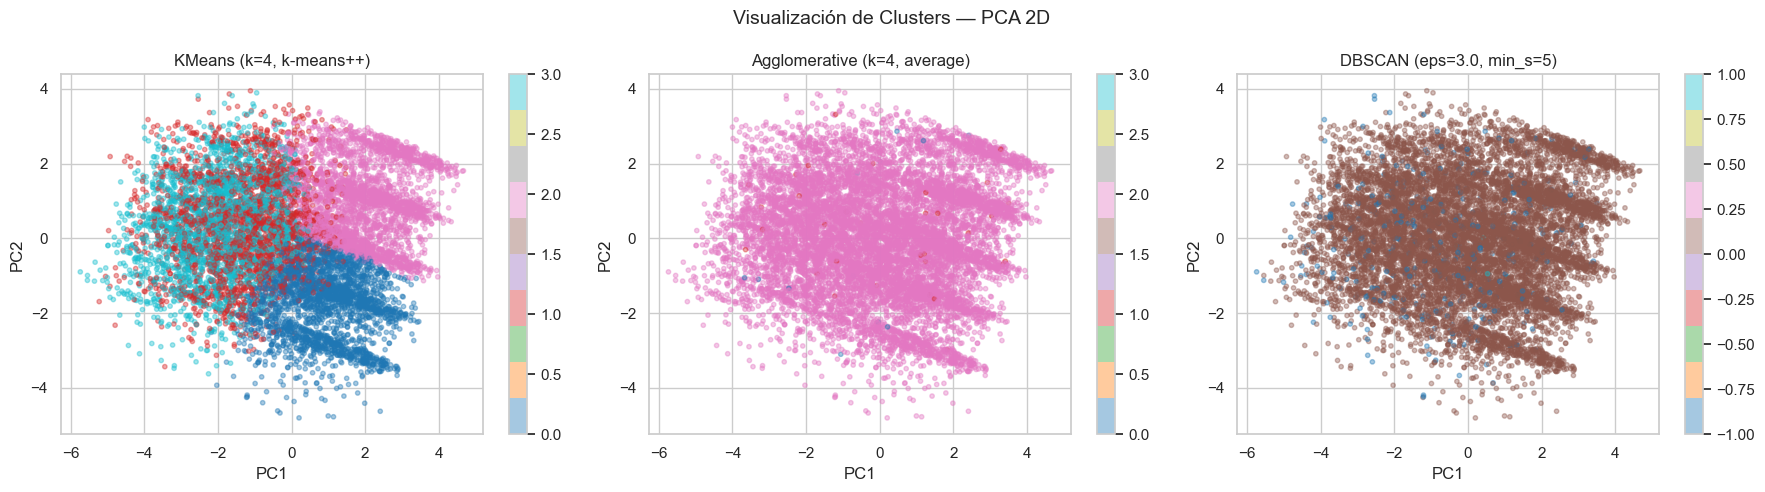

Gráfico guardado.


In [26]:
from sklearn.decomposition import PCA

# Reducción a 2 componentes
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)

print(f"Varianza explicada por componente: {pca.explained_variance_ratio_}")
print(f"Varianza total explicada: {pca.explained_variance_ratio_.sum():.4f}")

# Visualización de los 3 modelos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    (labels_kmeans, 'KMeans (k=4, k-means++)'),
    (labels_agg, 'Agglomerative (k=4, average)'),
    (labels_dbscan, 'DBSCAN (eps=3.0, min_s=5)')
]

for ax, (labels, title) in zip(axes, configs):
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                        c=labels, cmap='tab10',
                        alpha=0.4, s=10)
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    plt.colorbar(scatter, ax=ax)

plt.suptitle('Visualización de Clusters — PCA 2D', fontsize=14)
plt.tight_layout()
plt.savefig('clusters_pca.png', dpi=100, bbox_inches='tight')
plt.show()
print("Gráfico guardado.")

### 6.4 Análisis de la Visualización PCA 2D

Los dos componentes principales explican el **34.85% de la varianza
total** (PC1: 21.79%, PC2: 13.06%), lo que indica que el espacio de
22 dimensiones no se reduce fácilmente a 2D sin pérdida significativa
de información. Las visualizaciones deben interpretarse con esta
limitación en mente.

**KMeans (k=4, k-means++):**
Se observan 4 regiones de color diferenciadas. El cluster rosado
ocupa la zona superior derecha, el azul la zona inferior, y los
clusters rojo y cyan se distribuyen en la zona central. Existe
solapamiento en la región central, explicable por la pérdida de
varianza en la proyección 2D, no necesariamente por mala calidad
del clustering en el espacio original de 22 dimensiones.

**AgglomerativeClustering (k=4, average):**
La visualización confirma el efecto cadena: prácticamente todos los
puntos aparecen en un único color rosado (cluster 2 con 9.954
registros), con apenas unos pocos puntos de otros colores dispersos.
No hay segmentación visible útil.

**DBSCAN (eps=3.0, min_s=5):**
Idéntica situación: un único bloque marrón domina toda la
visualización con apenas 6 puntos en el cluster secundario.
Confirma la inutilidad práctica de este modelo para el caso.

La visualización PCA 2D refuerza la selección de **KMeans como el
mejor modelo**, siendo el único que muestra regiones diferenciadas
en el espacio reducido.

## 7. Evaluación Cualitativa

Una vez identificados los clusters con KMeans, se procede a caracterizar
cada grupo mediante estadísticas descriptivas y visualizaciones. El
objetivo es asignar etiquetas interpretables a cada cluster que sean
útiles para los objetivos de VuelaAlpes en las dimensiones de innovación,
capacitación y calidad.

In [27]:
# Agregar etiquetas KMeans al dataset limpio
df_kmeans = df_clean.copy()
df_kmeans['Cluster'] = labels_kmeans

# Estadísticas descriptivas por cluster
print("=== MEDIA POR CLUSTER ===")
print(df_kmeans.groupby('Cluster').mean(numeric_only=True).round(2).to_string())

print("\n=== VARIABLES CATEGÓRICAS POR CLUSTER ===")
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df_kmeans.groupby('Cluster')[col].value_counts().unstack().fillna(0).astype(int))

=== MEDIA POR CLUSTER ===
           Age  Flight Distance  Inflight wifi service  Departure/Arrival time convenient  Ease of Online booking  Gate location  Food and drink  Online boarding  Seat comfort  Inflight entertainment  On-board service  Leg room service  Baggage handling  Checkin service  Inflight service  Cleanliness  Arrival Delay in Minutes
Cluster                                                                                                                                                                                                                                                                                                                                
0        40.46          1308.60                   1.86                               2.15                    1.70           2.11            3.88             3.21          4.08                    4.31              3.97              3.75              4.19             3.61              4.19         4.03                 

### 7.1 Caracterización de los Clusters

Con base en las medias por cluster y la distribución de variables
categóricas, se identifican los siguientes perfiles:

**Cluster 0 — "Viajero de Negocios Satisfecho con Experiencia Física"**
- Edad media: 40.5 años | Distancia media: 1.309 km
- Calificaciones altas en experiencia a bordo: entretenimiento (4.31),
  comodidad del asiento (4.08), limpieza (4.03), manejo de equipaje (4.19)
- Calificaciones muy bajas en servicios digitales: wifi (1.86),
  reserva online (1.70), horario conveniente (2.15)
- 83% Loyal Customer | 59% clase Business
- **Oportunidad para VuelaAlpes:** mejorar la oferta digital para
  este segmento fiel que ya valora la experiencia física

**Cluster 1 — "Viajero Leal Insatisfecho con Servicio de Cabina"**
- Edad media: 43.1 años | Distancia media: 1.101 km
- Calificaciones bajas en servicio a bordo (2.20), espacio para
  piernas (2.33), inflight service (2.32) y baggage handling (2.35)
- Calificaciones digitales moderadas: wifi (2.54), reserva online (2.71)
- 86% Loyal Customer con mezcla de clases Eco y Business
- **Oportunidad para VuelaAlpes:** focalizar capacitación de tripulación
  en atención al pasajero para retener a este segmento en riesgo

**Cluster 2 — "Viajero Premium Altamente Satisfecho"**
- Edad media: 41.5 años | Distancia media más alta: 1.445 km
- Calificaciones altas y consistentes en todas las dimensiones:
  digitales (wifi: 4.01, reserva: 3.96) y físicas (entretenimiento:
  4.25, comodidad: 4.14, servicio a bordo: 4.02)
- 88% Loyal Customer | 65% clase Business
- **Oportunidad para VuelaAlpes:** segmento de referencia a preservar
  y replicar, base para definir nuevos servicios premium

**Cluster 3 — "Viajero Joven Personal en Clase Eco Muy Insatisfecho"**
- Edad media más baja: 32.2 años | Distancia más corta: 887 km
- Calificaciones muy bajas en experiencia física: comida (1.79),
  comodidad (1.88), entretenimiento (1.96), limpieza (1.79)
- 32% Disloyal Customer (mayor proporción) | 54% clase Eco
- Mayor retraso promedio: 19.5 minutos
- **Oportunidad para VuelaAlpes:** segmento crítico con mayor riesgo
  de deserción, requiere mejora urgente en calidad del servicio Eco

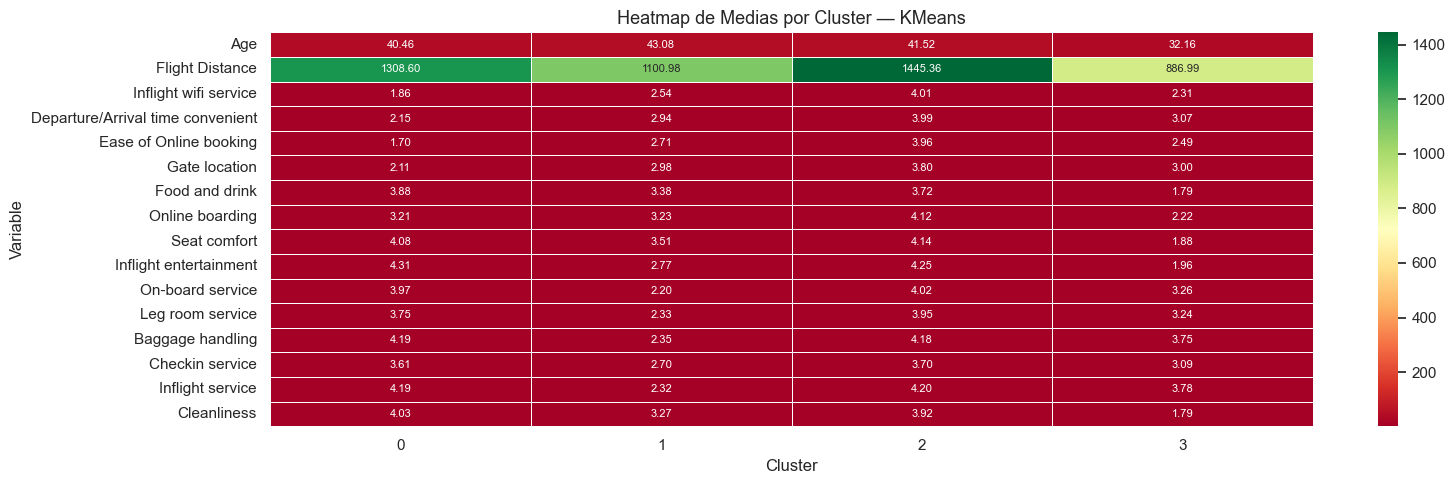

Gráfico guardado.


In [28]:
# Heatmap de medias por cluster
plt.figure(figsize=(16, 5))

numeric_means = df_kmeans.groupby('Cluster').mean(numeric_only=True)
numeric_means = numeric_means.drop(columns=['Arrival Delay in Minutes'])

sns.heatmap(numeric_means.T, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Heatmap de Medias por Cluster — KMeans', fontsize=13)
plt.xlabel('Cluster')
plt.ylabel('Variable')
plt.tight_layout()
plt.savefig('heatmap_clusters.png', dpi=100, bbox_inches='tight')
plt.show()
print("Gráfico guardado.")

### 7.2 Análisis del Heatmap

El heatmap confirma visualmente los perfiles identificados y permite
destacar patrones clave:

**Cluster 0 — "Viajero de Negocios Satisfecho con Experiencia Física":**
Patrón muy característico con calificaciones altas en experiencia
física (entretenimiento: 4.31, comodidad: 4.08, limpieza: 4.03) pero
las más bajas de todos los clusters en servicios digitales (wifi: 1.86,
reserva online: 1.70). La brecha entre lo físico y lo digital es la
más pronunciada del dataset.

**Cluster 1 — "Viajero Leal Insatisfecho con Servicio de Cabina":**
Calificaciones consistentemente bajas en servicios de cabina: servicio
a bordo (2.20), espacio para piernas (2.33), inflight service (2.32)
y baggage handling (2.35). Sin fortalezas claras en ninguna dimensión,
es el cluster con el perfil más homogéneamente mediocre.

**Cluster 2 — "Viajero Premium Altamente Satisfecho":**
Único cluster con calificaciones altas y consistentes en todas las
dimensiones, tanto digitales (wifi: 4.01, reserva: 3.96) como físicas
(entretenimiento: 4.25, comodidad: 4.14). Representa el segmento de
referencia que VuelaAlpes debe preservar y replicar.

**Cluster 3 — "Viajero Joven Personal en Clase Eco Muy Insatisfecho":**
El más crítico: calificaciones muy bajas y homogéneas en toda la
experiencia física (comida: 1.79, entretenimiento: 1.96, limpieza:
1.79, comodidad: 1.88). Es el segmento con mayor urgencia de
intervención por parte de VuelaAlpes.

**Nota sobre Flight Distance:**
La escala del heatmap está dominada por esta variable al estar en
magnitud diferente (31–4963 km) frente a las calificaciones (0–5).
El gráfico de barras de la siguiente sección permite comparar
exclusivamente las variables de calificación con mayor claridad.

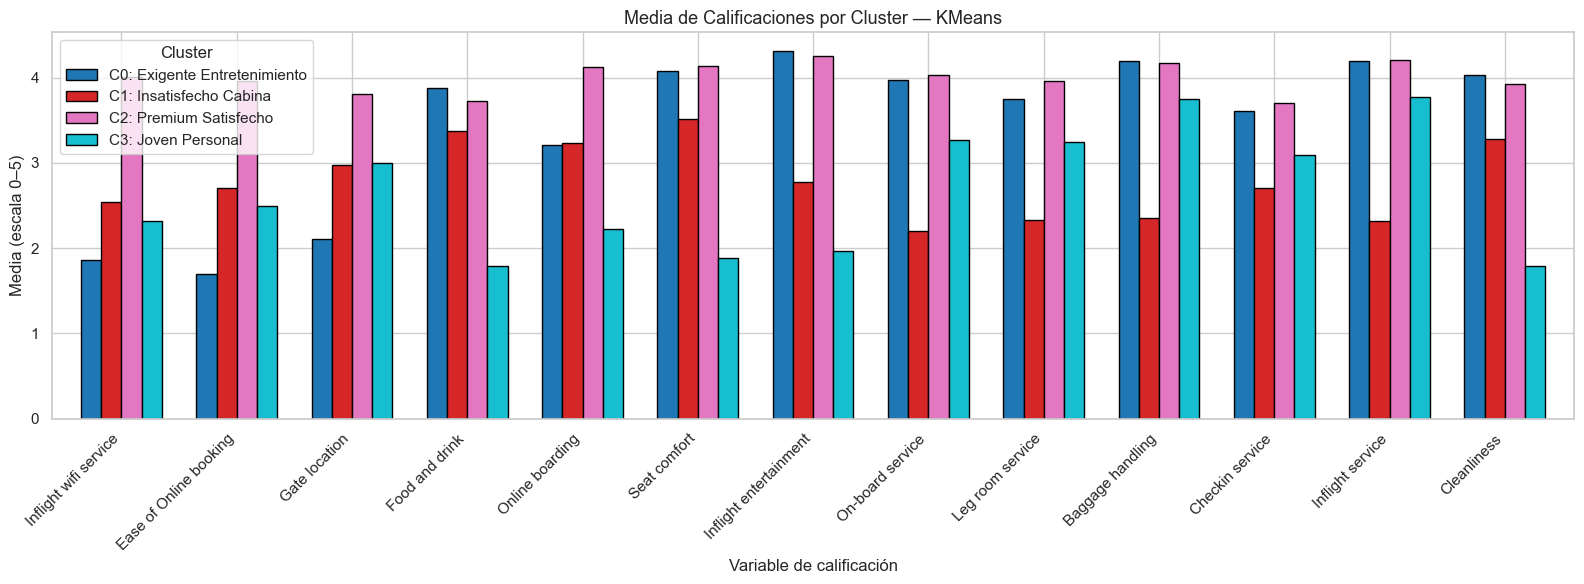

Gráfico guardado.


In [29]:
rating_cols_plot = [
    'Inflight wifi service', 'Ease of Online booking', 'Gate location',
    'Food and drink', 'Online boarding', 'Seat comfort',
    'Inflight entertainment', 'On-board service', 'Leg room service',
    'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness'
]

means_plot = df_kmeans.groupby('Cluster')[rating_cols_plot].mean()

means_plot.T.plot(kind='bar', figsize=(16, 6), colormap='tab10',
                  edgecolor='black', width=0.7)
plt.title('Media de Calificaciones por Cluster — KMeans', fontsize=13)
plt.xlabel('Variable de calificación')
plt.ylabel('Media (escala 0–5)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster', labels=[
    'C0: Exigente Entretenimiento',
    'C1: Insatisfecho Cabina',
    'C2: Premium Satisfecho',
    'C3: Joven Personal'
])
plt.tight_layout()
plt.savefig('barras_clusters.png', dpi=100, bbox_inches='tight')
plt.show()
print("Gráfico guardado.")

### 7.3 Análisis del Gráfico de Barras por Cluster

El gráfico de barras permite comparar las calificaciones exclusivamente
en la escala 0–5, confirmando y enriqueciendo los perfiles identificados:

**Cluster 2 — "Viajero Premium Altamente Satisfecho" (rosado):**
Lidera en prácticamente todas las variables, especialmente en servicios
digitales (wifi: 4.01, reserva online: 3.96) donde los demás clusters
muestran debilidad. Es el segmento de referencia de VuelaAlpes.

**Cluster 0 — "Viajero de Negocios Satisfecho con Experiencia Física" (azul):**
Patrón muy característico: lidera en entretenimiento (4.31) y es
competitivo en comodidad (4.08), manejo de equipaje (4.19) e inflight
service (4.19), pero cae dramáticamente en servicios digitales (wifi:
1.86, reserva online: 1.70). La brecha entre experiencia física y
digital es la más pronunciada de todos los clusters.

**Cluster 1 — "Viajero Leal Insatisfecho con Servicio de Cabina" (rojo):**
Calificaciones consistentemente bajas en servicios de cabina: servicio
a bordo (2.20), espacio para piernas (2.33) e inflight service (2.32).
Sus calificaciones digitales son moderadas, indicando que el problema
es de atención en vuelo, no tecnológico.

**Cluster 3 — "Viajero Joven Personal en Clase Eco Muy Insatisfecho" (cyan):**
El perfil más crítico: calificaciones muy bajas y homogéneas en toda
la experiencia a bordo (comida: 1.79, entretenimiento: 1.96, limpieza:
1.79, comodidad: 1.88). Es el segmento con mayor potencial de mejora
y mayor riesgo de deserción para VuelaAlpes.

**Implicaciones estratégicas para VuelaAlpes:**
- **Innovación:** desarrollar servicios digitales orientados al Cluster 0
  que ya es fiel pero está desconectado tecnológicamente
- **Capacitación:** enfocar entrenamiento de tripulación en atención
  al pasajero para el Cluster 1 en riesgo de perder fidelidad
- **Calidad:** mejorar integralmente la experiencia física en clase
  Eco para el Cluster 3, el segmento más insatisfecho

## 8. Análisis de Resultados

En esta sección se responden las preguntas planteadas en el laboratorio
con base en los resultados obtenidos, se comparan los algoritmos
utilizados y se identifican las limitaciones del estudio.

### 8.1 Respuesta a las Preguntas del Laboratorio

**1. ¿Qué restricciones tiene cada algoritmo? ¿Cómo afectan la calidad?**

- **KMeans:** requiere especificar `k` previamente y asume clusters
  esféricos de tamaño similar. Es sensible a outliers y a la escala
  de las variables, por lo que el escalado previo con StandardScaler
  fue fundamental. En este caso produjo clusters equilibrados y
  accionables gracias al preprocesamiento adecuado.

- **AgglomerativeClustering:** no requiere inicialización aleatoria
  pero su complejidad computacional es mayor O(n²). El linkage
  `average` produjo el efecto cadena, concentrando el 99.5% de
  registros en un único cluster a pesar de obtener Silhouette alto.
  Esto demuestra que las métricas cuantitativas no son suficientes
  para evaluar la utilidad práctica de una segmentación.

- **DBSCAN:** no requiere especificar `k` pero es extremadamente
  sensible a `eps` y `min_samples`. En este dataset de encuestas
  con variables en escala Likert, la densidad es uniforme y no
  permite identificar regiones densas diferenciadas, colapsando
  el 96% de registros en un único cluster independientemente de
  los hiperparámetros explorados.

**2. ¿Qué criterios son importantes para la selección del algoritmo?**

Los criterios clave son:
- **Naturaleza de los datos:** variables ordinales en escala Likert
  favorecen algoritmos basados en distancia como KMeans.
- **Forma de los clusters:** si se esperan clusters esféricos y de
  tamaño similar, KMeans es adecuado.
- **Escalabilidad:** con 10.000 registros, todos los algoritmos son
  viables computacionalmente.
- **Interpretabilidad:** KMeans produce centroides directamente
  interpretables, facilitando la caracterización de perfiles.
- **Utilidad para el negocio:** la segmentación debe producir grupos
  accionables y de tamaño suficiente para tomar decisiones.

**3. ¿Cómo medir la calidad? ¿Cómo saber que el modelo tiene buena calidad?**

Se utilizaron tres métricas intrínsecas complementarias:
- **Silhouette Score (0.1164):** valor moderado esperado en datasets
  de encuestas donde las percepciones son continuas y los clusters
  naturalmente se solapan. Valores entre 0.1 y 0.3 son aceptables
  en este contexto.
- **Calinski-Harabasz (1264.41):** muy superior al de los otros
  algoritmos, confirmando que los clusters de KMeans son los más
  compactos y separados entre sí de forma real.
- **Davies-Bouldin (2.270):** indica una separación moderada entre
  clusters, consistente con la naturaleza continua de las variables.

Un modelo tiene buena calidad cuando las métricas son consistentes
entre sí, los clusters son interpretables y accionables para el
negocio, y la segmentación es estable ante diferentes inicializaciones.

**4. ¿Cómo varía la calidad si se aplican diferentes algoritmos?**

| Algoritmo | Silhouette | Calinski-Harabasz | Davies-Bouldin | Utilidad práctica |
|---|---|---|---|---|
| KMeans | 0.1164 | 1264.41 | 2.2700 | Alta |
| Agglomerative | 0.2828 | 61.85 | 1.3720 | Nula (efecto cadena) |
| DBSCAN | 0.1540 | 8.58 | 1.2710 | Nula (cluster único) |

La calidad varía significativamente entre algoritmos. Agglomerative
y DBSCAN obtienen métricas aparentemente favorables pero producen
segmentaciones sin utilidad práctica. KMeans es el único que combina
métricas sólidas con segmentación equilibrada y accionable.

**5. ¿Cómo interpretar el resultado de los algoritmos de agrupación?**

Los 4 clusters de KMeans representan perfiles reales y diferenciados
de pasajeros de VuelaAlpes:
- **C0 - Viajero de Negocios Satisfecho con Experiencia Física:**
  fiel, valora lo físico pero rechaza lo digital
- **C1 - Viajero Leal Insatisfecho con Servicio de Cabina:**
  en riesgo, el servicio de tripulación es su mayor queja
- **C2 - Viajero Premium Altamente Satisfecho:**
  el segmento más valioso, satisfecho en todas las dimensiones
- **C3 - Viajero Joven Personal en Clase Eco Muy Insatisfecho:**
  el más crítico, con alta probabilidad de deserción

### 8.2 Limitaciones y Sesgos

- El Silhouette Score moderado (0.1164) refleja que los clusters
  no están perfectamente separados, lo cual es inherente a datos
  de encuestas con percepciones continuas y subjetivas.
- La varianza explicada por PCA 2D es solo del 34.85%, lo que
  significa que las visualizaciones capturan apenas un tercio de
  la información real del modelo.
- El dataset de 10.000 pasajeros puede no ser representativo de
  toda la operación de VuelaAlpes si la muestra no fue aleatoria.
- Las variables de calificación son subjetivas y pueden estar
  influenciadas por factores externos al momento de la encuesta
  como retrasos, clima o eventos personales del pasajero.
- DBSCAN y AgglomerativeClustering resultaron inadecuados para
  este tipo de dataset, lo que sugiere explorar en trabajos
  futuros algoritmos como GaussianMixture o SpectralClustering.

## 9. Uso de Herramientas de IA Generativa

### 9.1 Declaración de Uso

**Herramienta utilizada:** Claude (Anthropic) — modelo Claude Sonnet 4.6  
**Tipo de uso:** generación inicial de código, depuración de errores,
redacción técnica de análisis y explicación de conceptos teóricos.

### 9.2 Prompts Utilizados

Los prompts principales que influyeron directamente en el resultado del
laboratorio fueron:

1. *"Voy a desarrollar un laboratorio de clustering en Python usando
   scikit-learn. Me muestras el enunciado y vamos sección por sección"*
   → Definió la metodología de trabajo iterativa del laboratorio.

2. *"Búsqueda de hiperparámetros para KMeans, AgglomerativeClustering
   y DBSCAN usando silhouette score como métrica"*
   → Generó el código de búsqueda sistemática de hiperparámetros.

3. *"El AgglomerativeClustering con linkage=average da Silhouette de
   0.77 con k=2, ¿por qué?"*
   → Permitió identificar y explicar el efecto cadena del linkage average.

4. *"Construir pipeline con ColumnTransformer para preprocesar variables
   numéricas y categóricas"*
   → Generó la estructura del pipeline de preprocesamiento.

5. *"Caracterizar los 4 clusters de KMeans con base en las medias
   por cluster y variables categóricas"*
   → Apoyó la redacción de los perfiles de cada cluster.

### 9.3 Análisis Crítico del Resultado

**¿Qué partes del contenido generado fueron correctas y útiles?**
La estructura del pipeline de preprocesamiento con ColumnTransformer
fue correcta y directamente aplicable. El código de búsqueda de
hiperparámetros para los tres algoritmos funcionó correctamente y
permitió tomar decisiones informadas sobre la configuración final.

**¿Qué errores o limitaciones se identificaron?**
La IA inicialmente sugirió usar linkage='ward' para AgglomerativeClustering
sin explorar otras opciones. Al realizar la búsqueda sistemática se
identificó que 'average' obtenía mejor Silhouette, aunque posteriormente
se evidenció que producía el efecto cadena. Esto requirió un análisis
crítico adicional para entender que métricas altas no siempre implican
segmentaciones útiles. También se presentó un FutureWarning en pandas
3.0 con el método fillna que fue corregido manualmente.

**¿Qué decisiones técnicas fueron modificadas respecto a la IA?**
La selección final de k=4 sobre k=2 (que tenía mejor Silhouette) fue
una decisión propia basada en el contexto del negocio. Igualmente,
la decisión de mantener DBSCAN en la comparativa a pesar de sus
limitaciones fue una decisión argumentada desde el dominio del problema.

### 9.4 Aportes Propios del Estudiante

- La interpretación de los perfiles de cada cluster y su relación
  con los objetivos de VuelaAlpes (innovación, capacitación, calidad)
  fue desarrollada por los estudiantes con base en el dominio del problema.
- La decisión de seleccionar k=4 sobre k=2 a pesar de que el Silhouette
  favorecía k=2 fue argumentada por los estudiantes desde la utilidad
  para el negocio.
- La identificación del efecto cadena en AgglomerativeClustering y su
  implicación práctica fue un hallazgo propio al analizar críticamente
  los resultados numéricos vs la distribución real de los clusters.
- La justificación de eliminar `Departure Delay in Minutes` por su
  correlación de 0.96 con `Arrival Delay` fue una decisión propia
  basada en los conceptos de multicolinealidad vistos en el curso.